In [23]:
from rdkit import Chem

import pandas as pd

from chembl_structure_pipeline import standardizer

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from rdkit.Chem import Lipinski
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors

import seaborn as sns

In [2]:
suppl = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank_df = pd.DataFrame({"source": "drugbank", "mol": mol, "id": mol.GetProp("DATABASE_ID")} for mol in suppl if mol)
drugbank_df.set_index("id", inplace=True)
drugbank_df

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
...,...,...
DB13154,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
DB13155,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
DB13156,drugbank,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...


In [3]:
zinc_df = pd.read_csv("../data/zinc_random_structures.txt", delimiter=" ")
zinc_df.rename(columns={"zincid": "id"}, inplace=True)
zinc_df.set_index("id", inplace=True)
zinc_df['source'] = 'zinc'
zinc_df['mol'] = zinc_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
zinc_df.drop(columns=['tranche', 'SMILES'], inplace=True)
zinc_df

,source,mol
id,,
ZINCtA000001eUS8,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
ZINCpo00001BLwat,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
ZINCtz000004JjrO,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
ZINCsN000009NpXg,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
ZINCsN000009NsBY,zinc,<rdkit.Chem.rdchem.Mol object at 0x000001918EC...
...,...,...
ZINCrn00001eRwYj,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
ZINCsN000009Nrlo,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
ZINCtB00000oxE6f,zinc,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...


In [4]:
mtor_df = pd.read_csv("../data/chembl_mtor_ic50.csv", delimiter=";", usecols=["Molecule ChEMBL ID", "Smiles"])
mtor_df.rename(columns={"Molecule ChEMBL ID": "id"}, inplace=True)
mtor_df.set_index("id", inplace=True)
mtor_df['source'] = 'chembl'
mtor_df['mol'] = mtor_df['Smiles'].apply(lambda x: Chem.MolFromSmiles(x))
mtor_df.drop(columns=['Smiles'], inplace=True)
mtor_df

,source,mol
id,,
CHEMBL1773577,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
CHEMBL1773561,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
CHEMBL1773077,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
CHEMBL1773580,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
CHEMBL1773578,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198B...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198C...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198C...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198C...


In [5]:
structures = pd.concat([drugbank_df, zinc_df, mtor_df])
structures

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x0000019183C...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198C...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198C...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x0000019198C...


In [15]:
structures['mol'] = structures['mol'].apply(lambda x: standardizer.standardize_mol(x))
structures

,source,mol
id,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...
...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...


In [22]:
structures['HBA'] = structures['mol'].apply(lambda x: Lipinski.NumHAcceptors(x))
structures['HBD'] = structures['mol'].apply(lambda x: Lipinski.NumHDonors(x))
structures['LogP'] = structures['mol'].apply(lambda x: Descriptors.MolLogP(x))
structures['MW'] = structures['mol'].apply(lambda x: rdMolDescriptors.CalcExactMolWt(x))
structures

,source,mol,HBA,HBD,LogP,MW
id,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,29,28,-8.11643,2178.985813
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,16,17,-3.10570,1268.641439
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,15,14,-4.13203,1068.426955
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,16,17,-0.50613,1429.669818
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,12,5,3.26900,1201.841368
...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...,6,1,2.70500,426.079804
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...,5,1,3.48890,448.020845
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...,4,1,4.92340,407.126991


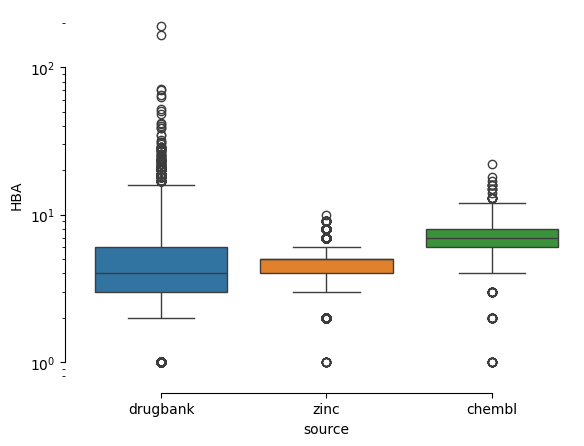

In [30]:
sns.boxplot(x="source", y="HBA", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

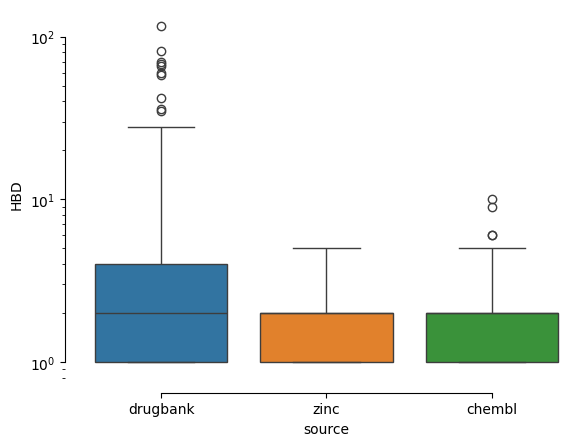

In [31]:
sns.boxplot(x="source", y="HBD", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

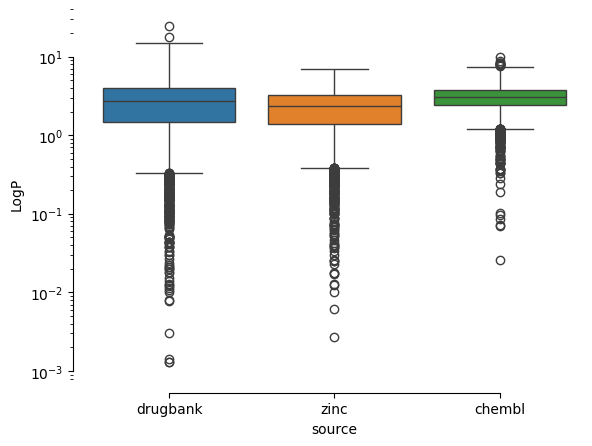

In [32]:
sns.boxplot(x="source", y="LogP", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

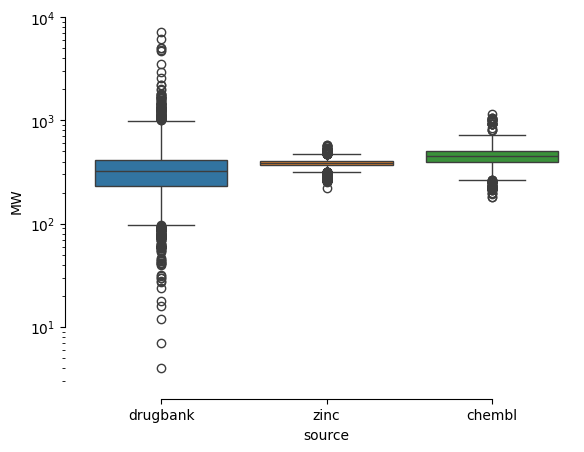

In [33]:
sns.boxplot(x="source", y="MW", hue="source", data=structures, log_scale=True)
sns.despine(offset=10, trim=True)

In [34]:
structures['SMILES'] = structures['mol'].apply(lambda x: Chem.MolToSmiles(x))
structures

,source,mol,HBA,HBD,LogP,MW,SMILES
id,,,,,,,
DB00006,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,29,28,-8.11643,2178.985813,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...
DB00014,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,16,17,-3.10570,1268.641439,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...
DB00035,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,15,14,-4.13203,1068.426955,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...
DB00050,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,16,17,-0.50613,1429.669818,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...
DB00091,drugbank,<rdkit.Chem.rdchem.Mol object at 0x00000191BC8...,12,5,3.26900,1201.841368,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...
...,...,...,...,...,...,...,...
CHEMBL4287809,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...,6,1,2.70500,426.079804,COc1ncc(-c2ccc3nccc(=O)n3c2)cc1NS(=O)(=O)c1ccc...
CHEMBL4280265,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...,5,1,3.48890,448.020845,O=c1ccnc2ccc(-c3cnc(Cl)c(NS(=O)(=O)c4ccc(F)cc4...
CHEMBL4246563,chembl,<rdkit.Chem.rdchem.Mol object at 0x00000191BCF...,4,1,4.92340,407.126991,C=CC(=O)Nc1ccc(-n2c(=O)ccc3oc4ccc(-c5cccnc5)cc...


In [35]:
structures.to_csv('../data/standardized_structures.csv', columns=['source', 'SMILES'])